# Student Dropout Prediction - Model Training

This notebook trains the final MVP pipeline using the fixed 10 enrollment/background features. It compares Logistic Regression and Random Forest, then saves the best final pipeline and metadata.

In [13]:
# Import libraries used for modeling.
from pathlib import Path
import json

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Load Processed Data

The processed dataset already contains only Graduate/Dropout records and the fixed MVP feature scope.

In [14]:
# Resolve paths.
current_path = Path.cwd()

if (current_path / "data" / "processed" / "processed.csv").exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "processed.csv"
FEATURE_CONFIG_PATH = PROJECT_ROOT / "app" / "feature_config.json"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODEL_DIR / "final_mvp_model.pkl"
MVP_FEATURES_PATH = MODEL_DIR / "mvp_features.json"
MODEL_METADATA_PATH = MODEL_DIR / "model_metadata.json"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data path:", PROCESSED_DATA_PATH)
print("Model path:", MODEL_PATH)
print("Metadata path:", MODEL_METADATA_PATH)
print("Figures directory:", FIGURES_DIR)

Processed data path: e:\Projects\student-dropout-prediction-ml\data\processed\processed.csv
Model path: e:\Projects\student-dropout-prediction-ml\models\final_mvp_model.pkl
Metadata path: e:\Projects\student-dropout-prediction-ml\models\model_metadata.json
Figures directory: e:\Projects\student-dropout-prediction-ml\reports\figures


In [15]:
# Load data and config.
df_processed = pd.read_csv(PROCESSED_DATA_PATH)

with open(FEATURE_CONFIG_PATH, "r", encoding="utf-8") as file:
    feature_config = json.load(file)

candidate_mvp_features = feature_config["features"]

print("Processed dataset shape:", df_processed.shape)
print("Target distribution:")
print(df_processed["Target"].value_counts().sort_index())

df_processed.head()

Processed dataset shape: (3630, 11)
Target distribution:
Target
0    2209
1    1421
Name: count, dtype: int64


,Marital status,Course,Previous qualification,Mother's qualification,Father's qualification,Displaced,Educational special needs,Gender,Age at enrollment,International,Target
0,1,2,1,13,10,1,0,1,20,0,1
1,1,11,1,1,3,1,0,1,19,0,0
2,1,5,1,22,27,1,0,1,19,0,1
3,1,15,1,23,27,1,0,0,20,0,0
4,2,3,1,22,28,0,0,0,45,0,0


## Define Features

`Age at enrollment` is the only continuous feature. All other selected features are treated as categorical-like encoded fields.

In [16]:
# Define feature matrix and target.
X = df_processed[candidate_mvp_features].copy()
y = df_processed["Target"].copy()

# Define continuous features.
continuous_features = [
    "Age at enrollment"
]

# Define categorical-like features.
categorical_features = [
    col for col in X.columns
    if col not in continuous_features
]

print("Continuous features:", continuous_features)
print("Categorical features:", categorical_features)

Continuous features: ['Age at enrollment']
Categorical features: ['Marital status', 'Course', 'Previous qualification', "Mother's qualification", "Father's qualification", 'Displaced', 'Educational special needs', 'Gender', 'International']


## Train, Validation, and Test Split

The validation set is used to choose between the two models. The test set is kept for final evaluation.

In [17]:
# Split data into train, validation, and test sets.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

Train shape: (2178, 10)
Validation shape: (726, 10)
Test shape: (726, 10)


## Build Preprocessor and Models

OneHotEncoder handles categorical fields, while StandardScaler scales the continuous age feature. Logistic Regression is the interpretable baseline; Random Forest is the non-linear comparison model.

In [18]:
# Build preprocessing pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("continuous", StandardScaler(), continuous_features)
    ],
    remainder="drop"
)

# Define classification models.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200,
                        random_state=42)}

## Model Comparison

Models are compared on validation metrics, with F1-score used as the main selection metric because Dropout is the positive risk class.

In [19]:
# Train and evaluate each model on the validation set.
def evaluate_model(name, pipeline, X_eval, y_eval):
    y_pred = pipeline.predict(X_eval)
    y_proba = pipeline.predict_proba(X_eval)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1-Score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_proba)
    }

validation_results = []
fitted_validation_pipelines = {}

for model_name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(estimator))
    ])

    pipeline.fit(X_train, y_train)
    fitted_validation_pipelines[model_name] = pipeline
    validation_results.append(evaluate_model(model_name, pipeline, X_valid, y_valid))

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values(["F1-Score", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

validation_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.698347,0.661692,0.468310,0.548454,0.749793
1,Random Forest,0.658402,0.573770,0.492958,0.530303,0.687647


## Validation Visualizations

This section visualizes model comparison on the validation set. The plots are saved to `reports/figures/` so they can be reused in the final PPT.

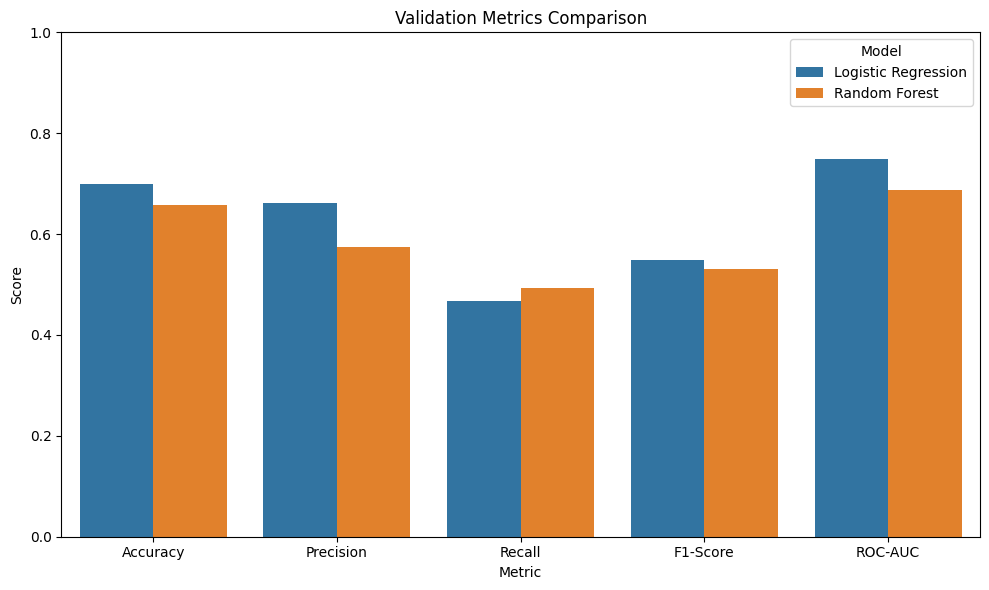

In [20]:
# Plot validation metrics comparison.
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

validation_metrics_long = validation_results_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=validation_metrics_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Validation Metrics Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "validation_metrics_comparison.png", dpi=300)
plt.show()

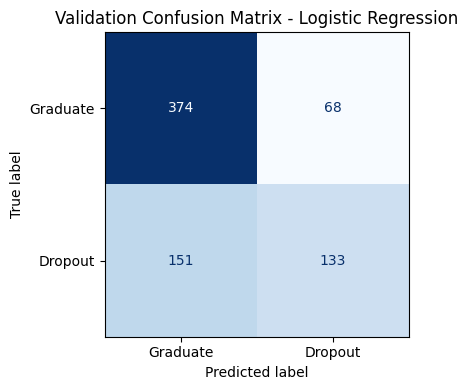

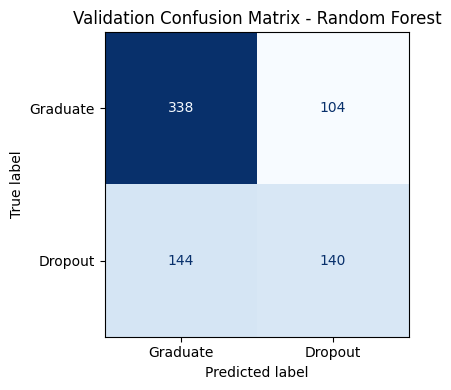

In [21]:
# Plot validation confusion matrix for each model.
for model_name, pipeline in fitted_validation_pipelines.items():
    y_valid_pred = pipeline.predict(X_valid)

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_valid,
        y_valid_pred,
        display_labels=["Graduate", "Dropout"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"Validation Confusion Matrix - {model_name}")
    plt.tight_layout()

    filename = f"validation_confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES_DIR / filename, dpi=300)
    plt.show()

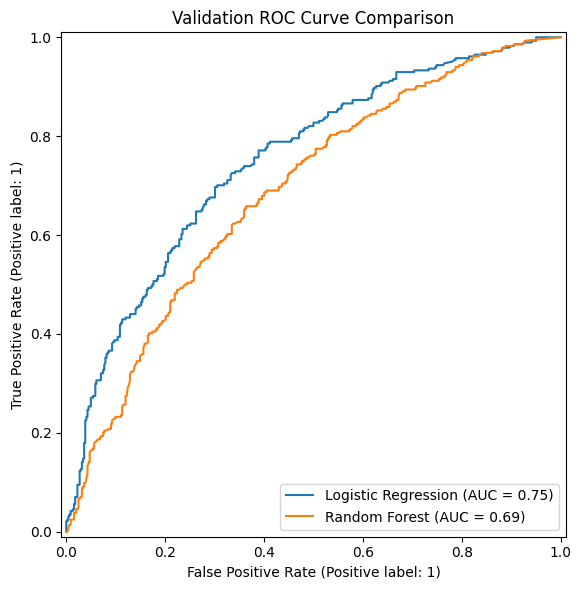

In [22]:
# Plot validation ROC curve comparison.
fig, ax = plt.subplots(figsize=(7, 6))

for model_name, pipeline in fitted_validation_pipelines.items():
    RocCurveDisplay.from_estimator(
        pipeline,
        X_valid,
        y_valid,
        name=model_name,
        ax=ax
    )

ax.set_title("Validation ROC Curve Comparison")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "validation_roc_curve_comparison.png", dpi=300)
plt.show()

In [23]:
# Create validation classification report table for each model.
classification_report_rows = []

for model_name, pipeline in fitted_validation_pipelines.items():
    y_valid_pred = pipeline.predict(X_valid)

    report = classification_report(
        y_valid,
        y_valid_pred,
        target_names=["Graduate", "Dropout"],
        output_dict=True,
        zero_division=0
    )

    for label in ["Graduate", "Dropout"]:
        classification_report_rows.append({
            "Model": model_name,
            "Class": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1-Score": report[label]["f1-score"],
            "Support": report[label]["support"]
        })

validation_classification_report_df = pd.DataFrame(classification_report_rows)

validation_classification_report_df.to_csv(
    REPORTS_DIR / "validation_classification_report.csv",
    index=False
)

validation_classification_report_df

,Model,Class,Precision,Recall,F1-Score,Support
0,Logistic Regression,Graduate,0.712381,0.846154,0.773526,442.0
1,Logistic Regression,Dropout,0.661692,0.468310,0.548454,284.0
2,Random Forest,Graduate,0.701245,0.764706,0.731602,442.0
3,Random Forest,Dropout,0.573770,0.492958,0.530303,284.0


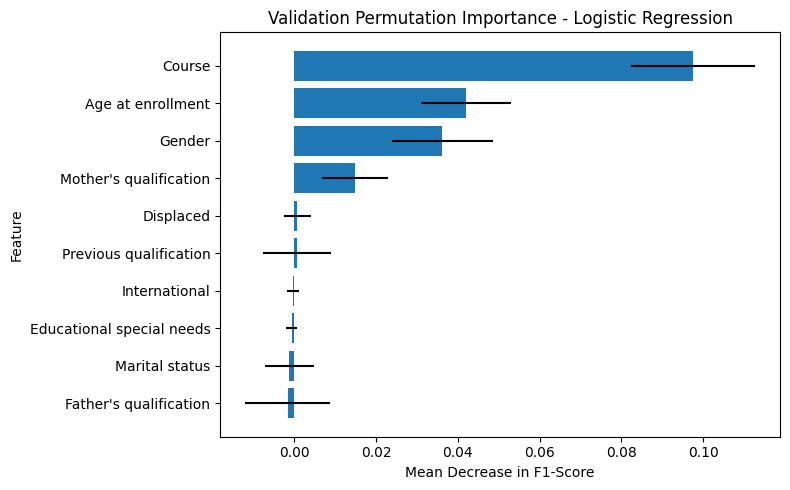

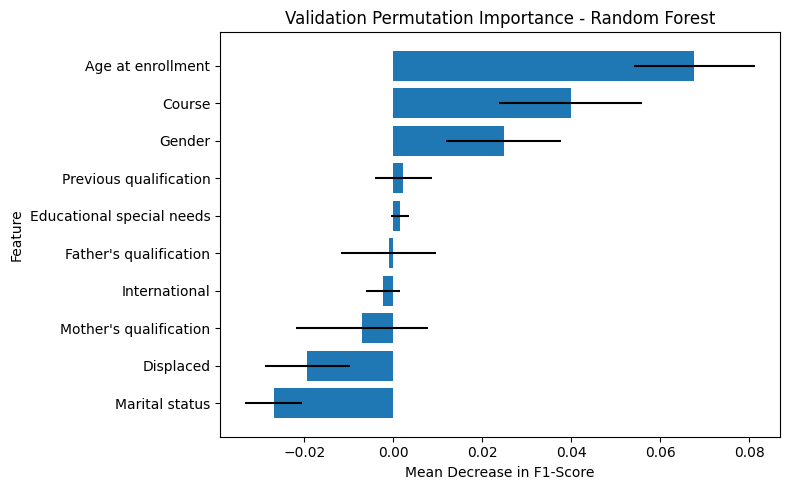

,feature,importance_mean,importance_std
0,Course,0.097467,0.015119
1,Age at enrollment,0.041893,0.011004
2,Gender,0.036255,0.012324
3,Mother's qualification,0.014877,0.008030
4,Displaced,0.000765,0.003232
5,Previous qualification,0.000676,0.008262
6,International,-0.000259,0.001449
7,Educational special needs,-0.000670,0.001344
8,Marital status,-0.001193,0.006042
9,Father's qualification,-0.001553,0.010382


In [24]:
# Calculate and plot permutation feature importance for each validation model.
validation_permutation_importance = {}

for model_name, pipeline in fitted_validation_pipelines.items():
    perm_result = permutation_importance(
        pipeline,
        X_valid,
        y_valid,
        scoring="f1",
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    perm_df = (
        pd.DataFrame({
            "feature": X_valid.columns,
            "importance_mean": perm_result.importances_mean,
            "importance_std": perm_result.importances_std
        })
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    validation_permutation_importance[model_name] = perm_df

    top_perm = perm_df.head(10).sort_values("importance_mean")

    plt.figure(figsize=(8, 5))
    plt.barh(
        top_perm["feature"],
        top_perm["importance_mean"],
        xerr=top_perm["importance_std"]
    )

    plt.title(f"Validation Permutation Importance - {model_name}")
    plt.xlabel("Mean Decrease in F1-Score")
    plt.ylabel("Feature")
    plt.tight_layout()

    filename = f"validation_permutation_importance_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES_DIR / filename, dpi=300)
    plt.show()

validation_permutation_importance[best_model_name].head(10)

In [25]:
# Select the best model from validation performance.
best_model_name = validation_results_df.loc[0, "Model"]

print("Best model:", best_model_name)

Best model: Logistic Regression


## Final Model Evaluation

The best estimator is retrained on train + validation data, then evaluated once on the test set.

In [26]:
# Train final model using train + validation data.
final_estimator = clone(models[best_model_name])

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_estimator)
])

final_pipeline.fit(X_train_full, y_train_full)

final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('continuous', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [27]:
# Evaluate the final model on the test set.
final_evaluation = evaluate_model("Final Test Evaluation", final_pipeline, X_test, y_test)
final_evaluation_df = pd.DataFrame([final_evaluation])

y_test_pred = final_pipeline.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, target_names=["Graduate", "Dropout"]))

final_evaluation_df

Confusion matrix:
[[354  88]
 [128 156]]

Classification report:
              precision    recall  f1-score   support

    Graduate       0.73      0.80      0.77       442
     Dropout       0.64      0.55      0.59       284

    accuracy                           0.70       726
   macro avg       0.69      0.68      0.68       726
weighted avg       0.70      0.70      0.70       726



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Final Test Evaluation,0.702479,0.639344,0.549296,0.590909,0.758608


## Final Test Visualizations

The final selected model is evaluated once on the held-out test set. These plots are used for the final report and presentation.

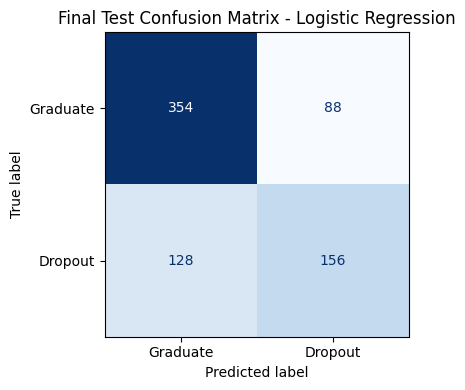

In [28]:
# Plot final test confusion matrix.
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Graduate", "Dropout"],
    cmap="Blues",
    ax=ax,
    colorbar=False
)

ax.set_title(f"Final Test Confusion Matrix - {best_model_name}")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "final_test_confusion_matrix.png", dpi=300)
plt.show()

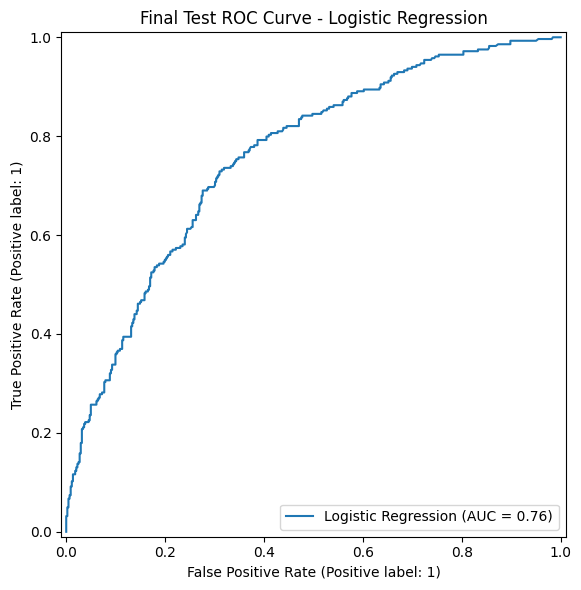

In [29]:
# Plot final test ROC curve.
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_estimator(
    final_pipeline,
    X_test,
    y_test,
    name=best_model_name,
    ax=ax
)

ax.set_title(f"Final Test ROC Curve - {best_model_name}")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "final_test_roc_curve.png", dpi=300)
plt.show()

In [30]:
# Save validation and final test evaluation tables.
validation_results_df.to_csv(
    REPORTS_DIR / "validation_model_comparison.csv",
    index=False
)

final_evaluation_df.to_csv(
    REPORTS_DIR / "final_model_evaluation.csv",
    index=False
)

print("Validation comparison saved:", (REPORTS_DIR / "validation_model_comparison.csv").exists())
print("Final evaluation saved:", (REPORTS_DIR / "final_model_evaluation.csv").exists())

Validation comparison saved: True
Final evaluation saved: True


## Feature Importance for Interpretation

Feature importance is reported only for interpretation. It is not used to select or remove MVP features.

In [31]:
# Show feature importance when the selected final model exposes it.
if hasattr(final_pipeline.named_steps["model"], "feature_importances_"):
    transformed_feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importance_df = (
        pd.DataFrame({
            "feature": transformed_feature_names,
            "importance": final_pipeline.named_steps["model"].feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
else:
    importance_df = pd.DataFrame(columns=["feature", "importance"])

importance_df.head(20)

,feature,importance


## Final Feature Importance Visualizations

Feature importance is used for interpretation only. The model still uses the fixed candidate feature set defined in the preprocessing stage.

In [32]:
# Plot model-native feature importance when available.
if not importance_df.empty:
    top_importance = importance_df.head(20).sort_values("importance")

    plt.figure(figsize=(8, 7))
    plt.barh(
        top_importance["feature"],
        top_importance["importance"]
    )

    plt.title(f"Model-Native Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Transformed Feature")
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / "model_native_feature_importance.png", dpi=300)
    plt.show()
else:
    print("Model-native feature importance is not available for the selected model.")

Model-native feature importance is not available for the selected model.


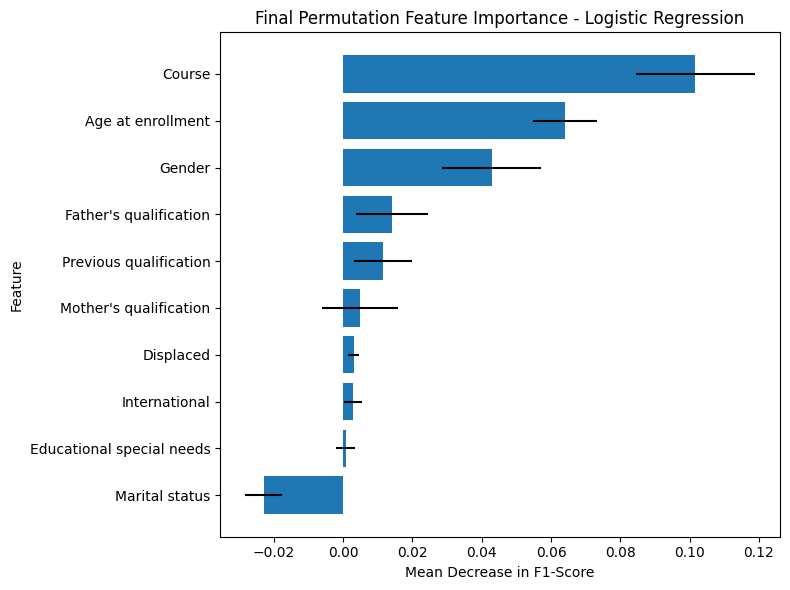

,feature,importance_mean,importance_std
0,Course,0.101630,0.017127
1,Age at enrollment,0.063954,0.009294
2,Gender,0.042914,0.014243
3,Father's qualification,0.014131,0.010461
4,Previous qualification,0.011559,0.008449
5,Mother's qualification,0.004808,0.010880
6,Displaced,0.003007,0.001697
7,International,0.002811,0.002541
8,Educational special needs,0.000691,0.002699
9,Marital status,-0.022901,0.005296


In [33]:
# Calculate and plot final permutation feature importance on the test set.
final_perm_result = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

final_permutation_importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": final_perm_result.importances_mean,
        "importance_std": final_perm_result.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

final_permutation_importance_df.to_csv(
    REPORTS_DIR / "final_permutation_feature_importance.csv",
    index=False
)

top_final_perm = final_permutation_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_final_perm["feature"],
    top_final_perm["importance_mean"],
    xerr=top_final_perm["importance_std"]
)

plt.title(f"Final Permutation Feature Importance - {best_model_name}")
plt.xlabel("Mean Decrease in F1-Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "final_permutation_feature_importance.png", dpi=300)
plt.show()

final_permutation_importance_df

## Save Model Artifacts

The saved metadata uses the fixed 10 MVP features from config, not a feature-selection output.

In [34]:
# Save model, fixed MVP features, and metadata.
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(final_pipeline, MODEL_PATH)

with open(MVP_FEATURES_PATH, "w", encoding="utf-8") as file:
    json.dump(candidate_mvp_features, file, indent=4)

model_metadata = {
    "model_name": "Final Student Dropout Prediction Model",
    "base_model": best_model_name,
    "target_mapping": {
        "Graduate": 0,
        "Dropout": 1
    },
    "positive_class": "Dropout",
    "positive_class_value": 1,
    "mvp_feature_count": len(candidate_mvp_features),
    "mvp_features": candidate_mvp_features,
    "continuous_features": continuous_features,
    "categorical_features": categorical_features,
    "selection_metric": "F1-Score",
    "validation_results": validation_results_df.to_dict(orient="records"),
    "evaluation": final_evaluation_df.to_dict(orient="records")
}

with open(MODEL_METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(model_metadata, file, indent=4)

print("Model saved:", MODEL_PATH.exists())
print("MVP features saved:", MVP_FEATURES_PATH.exists())
print("Model metadata saved:", MODEL_METADATA_PATH.exists())

model_metadata

Model saved: True
MVP features saved: True
Model metadata saved: True


{'model_name': 'Final Student Dropout Prediction Model',
 'base_model': 'Logistic Regression',
 'target_mapping': {'Graduate': 0, 'Dropout': 1},
 'positive_class': 'Dropout',
 'positive_class_value': 1,
 'mvp_feature_count': 10,
 'mvp_features': ['Marital status',
  'Course',
  'Previous qualification',
  "Mother's qualification",
  "Father's qualification",
  'Displaced',
  'Educational special needs',
  'Gender',
  'Age at enrollment',
  'International'],
 'continuous_features': ['Age at enrollment'],
 'categorical_features': ['Marital status',
  'Course',
  'Previous qualification',
  "Mother's qualification",
  "Father's qualification",
  'Displaced',
  'Educational special needs',
  'Gender',
  'International'],
 'selection_metric': 'F1-Score',
 'validation_results': [{'Model': 'Logistic Regression',
   'Accuracy': 0.6983471074380165,
   'Precision': 0.6616915422885572,
   'Recall': 0.46830985915492956,
   'F1-Score': 0.5484536082474227,
   'ROC-AUC': 0.7497928748964375},
  {'Mode

## Modeling Summary

- The final experiment uses fixed enrollment/background MVP features from start to finish.
- Logistic Regression provides a simple interpretable baseline.
- Random Forest provides a stronger non-linear comparison for categorical-heavy tabular data.
- Feature importance is interpretive only; it does not change the fixed MVP scope.